In [ ]:
# Update files
import importlib
import utils.io
import data.data_loader
import models.multi_layer_perceptron
import models.convolutional_neural_networks
import utils.metrics
import config as cfg
importlib.reload(utils.io)
importlib.reload(data.data_loader)
importlib.reload(cfg)
importlib.reload(utils.metrics)
importlib.reload(models.multi_layer_perceptron)
importlib.reload(models.convolutional_neural_networks)


# Import libraries  
import pandas as pd
import torch
import torchvision.transforms as transforms
import torch.optim as optim
import torch.utils.data as data
import torch.nn as nn
import matplotlib.pyplot as plt

# Choose device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():    
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

ModuleNotFoundError: No module named 'utils'

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [52]:
from data.data_loader import ButterflyDataset
from utils.io import print_images
from utils.metrics import analyze_df
from sklearn.model_selection import train_test_split

# load the data
df = pd.read_csv(cfg.TRAIN_LABELS_PATH)

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor()
])

train_dataset = ButterflyDataset(df=df_train, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
val_dataset = ButterflyDataset(df=df_val, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)

train_loader = data.DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
print("All images proccessed...")


All images proccessed...


#### TRAIN DATASET ####
------------------------------
Número de classes: 75
Número de inputs para o MLP: 12288
------------------------------
------------------------------
                          Quantidade de Imagens  Proporção (%)
label                                                         
MOURNING CLOAK                               84       2.019716
SLEEPY ORANGE                                68       1.635008
ATALA                                        64       1.538831
BROWN SIPROETA                               63       1.514787
BANDED ORANGE HELICONIAN                     62       1.490743
...                                         ...            ...
AMERICAN SNOOT                               47       1.130079
GOLD BANDED                                  46       1.106035
WOOD SATYR                                   46       1.106035
CRIMSON PATCH                                46       1.106035
MALACHITE                                    46       1.106035

[75 ro

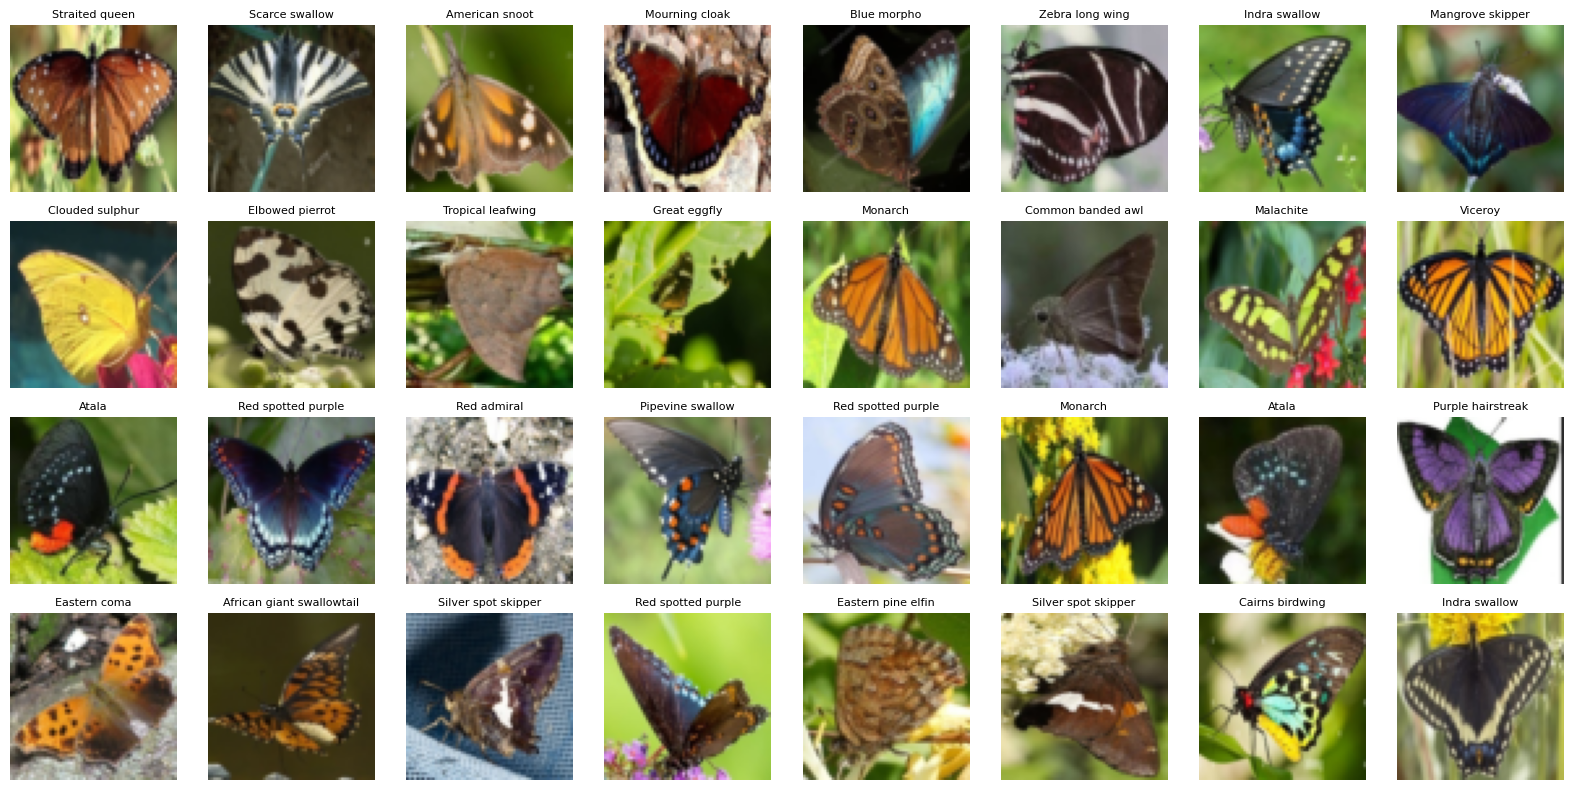

In [53]:
# Train data set analyze
print("#### TRAIN DATASET ####")
num_inputs, num_classes = analyze_df(df_train, train_dataset)
print_images(train_dataset, train_loader)

MLP

In [ ]:
import torch.nn as nn
import torch.optim as optim
from models.multi_layer_perceptron import MLP, fit

dnn = MLP(input_size=num_inputs, hidden_sizes=cfg.MLP_HIDDEN_LAYER_SIZES, num_classes=num_classes)

# Escolher Loss Function
if cfg.MLP_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.MLP_LOSS_FUNCTION == "CrossEntropy_LabelSmoothing":
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.MLP_LABEL_SMOOTHING) 
elif cfg.MLP_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.MLP_LOSS_FUNCTION}")

# Escolher Otimizador
if cfg.MLP_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAM":
    optimizer = optim.Adam(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAMW":
    optimizer = optim.AdamW(dnn.parameters(), lr=cfg.MLP_LR, weight_decay=cfg.MLP_WEIGHT_DECAY)
elif cfg.MLP_OPTIM == "SGD":
    optimizer = optim.SGD(dnn.parameters(), lr=cfg.MLP_LR, momentum=cfg.MLP_MOMENTUM)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.MLP_OPTIM}")

# Treino
print(f"A iniciar o treino com {cfg.MLP_OPTIM} e {cfg.MLP_LOSS_FUNCTION}...")
train_losses, val_losses, dnn = fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    nn=dnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.MLP_EPOCHS, 
    to_device=False
)

A iniciar o treino com ADAMW e CrossEntropy...
Epoch [1/50], Train Loss: 4.2180 | Val Loss: 3.9312
Epoch [2/50], Train Loss: 3.6309 | Val Loss: 3.4859
Epoch [3/50], Train Loss: 3.3402 | Val Loss: 3.1807
Epoch [4/50], Train Loss: 3.0835 | Val Loss: 3.0823
Epoch [5/50], Train Loss: 2.8892 | Val Loss: 3.0372
Epoch [6/50], Train Loss: 2.7400 | Val Loss: 2.8621
Epoch [7/50], Train Loss: 2.5777 | Val Loss: 2.8308
Epoch [8/50], Train Loss: 2.4549 | Val Loss: 2.8184
Epoch [9/50], Train Loss: 2.3457 | Val Loss: 2.8336
Epoch [10/50], Train Loss: 2.2529 | Val Loss: 2.7069
Epoch [11/50], Train Loss: 2.1286 | Val Loss: 2.6372
Epoch [12/50], Train Loss: 2.0041 | Val Loss: 2.6210
Epoch [13/50], Train Loss: 1.9300 | Val Loss: 2.7095
Epoch [14/50], Train Loss: 1.8233 | Val Loss: 2.6899
Epoch [15/50], Train Loss: 1.7451 | Val Loss: 2.8714
Epoch [16/50], Train Loss: 1.6938 | Val Loss: 2.7902
Epoch [17/50], Train Loss: 1.5663 | Val Loss: 2.8281
Epoch [18/50], Train Loss: 1.4693 | Val Loss: 2.8661
Epoch [1

In [55]:
from utils.metrics import evaluate_network, save_loss_graph

print('Saving graphics showing loss results...')
save_loss_graph(train_losses, val_losses)

print('Evaluating with the training data...')
evaluate_network(
    net=dnn, 
    dataloader=train_loader, 
    device="cpu", # Muda para cuda se usares GPU
    save_path=cfg.mlp_results_path, 
    split_name="Treino"
)

print('Evaluating with the valid data...')
evaluate_network(
    net=dnn, 
    dataloader=val_loader, 
    device="cpu", 
    save_path=cfg.mlp_results_path, 
    split_name="Validacao"
)

Saving graphics showing loss results...
Gráfico guardado com sucesso...
Evaluating with the training data...
[Treino] F1 Score: 0.9682
Métricas de Treino salvas...
Evaluating with the valid data...
[Validacao] F1 Score: 0.3350
Métricas de Validacao salvas...


(0.3349853064742853,
 array([[12,  0,  0, ...,  0,  0,  0],
        [ 0,  6,  1, ...,  0,  0,  0],
        [ 0,  0,  2, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  4,  1,  0],
        [ 0,  0,  0, ...,  0,  4,  0],
        [ 0,  0,  0, ...,  0,  0,  2]]))

CNN

In [ ]:
import torch.nn as nn
import torch.optim as optim
from models.convolutional_neural_networks import CNN, fit

cnn = CNN(input_channels=3, num_classes=num_classes)


# Escolher Loss Function
if cfg.CNN_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.CNN_LOSS_FUNCTION == "CrossEntropy_LabelSmoothing":
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.CNN_LABEL_SMOOTHING) 
elif cfg.CNN_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.CNN_LOSS_FUNCTION}")

# Escolher Otimizador
if cfg.CNN_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(cnn.parameters(), lr=cfg.CNN_LR)
elif cfg.CNN_OPTIM == "ADAM":
    optimizer = optim.Adam(cnn.parameters(), lr=cfg.CNN_LR)
elif cfg.CNN_OPTIM == "ADAMW":
    optimizer = optim.AdamW(cnn.parameters(), lr=cfg.CNN_LR, weight_decay=cfg.CNN_WEIGHT_DECAY)
elif cfg.CNN_OPTIM == "SGD":
    optimizer = optim.SGD(cnn.parameters(), lr=cfg.CNN_LR, momentum=cfg.CNN_MOMENTUM)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.CNN_OPTIM}")

# Treino
print(f"\nA iniciar o treino da CNN com {cfg.CNN_OPTIM} e {cfg.CNN_LOSS_FUNCTION}...")
cnn_train_losses, cnn_val_losses, cnn = fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    nn=cnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.CNN_EPOCHS, 
    to_device=False,     # Alterado para True para ser mais rápido (usa CUDA/MPS)
    device=device       # Passamos a variável device que definiste no topo
)

In [ ]:
from utils.metrics import evaluate_network, save_loss_graph

print('Saving graphics showing loss results...')
save_loss_graph(train_losses, val_losses)

print('Evaluating with the training data...')
evaluate_network(
    net=dnn, 
    dataloader=train_loader, 
    device="cpu", # Muda para cuda se usares GPU
    save_path=cfg.cnn_results_path, 
    split_name="Treino"
)

print('Evaluating with the valid data...')
evaluate_network(
    net=dnn, 
    dataloader=val_loader, 
    device="cpu", 
    save_path=cfg.cnn_results_path, 
    split_name="Validacao"
)